# 31 -- Do the conditioning attributes actually vary?

At k = 3 the dataset takes `sorted(t*.tif)[:3]`, so only t0, t1 and t2
reach the model. If orbit direction and relative orbit are the same across
those three views, two of the three real attributes are constants and carry
no information -- which would explain the +0.031 (p = 0.28) null in
Section 4.

CPU only. No GPU, no model, no sampling. Runs in seconds.


In [1]:
# Orbit-direction diversity in the attributes the model actually sees.
# At k=3 the dataset takes sorted(t*.tif)[:3], i.e. t0, t1, t2 only.

import json
from pathlib import Path
from collections import Counter

WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
CONTEXT_K = 3

patch_dirs = sorted(S1_DIR.glob('s1_patch_*'))
print(f'patches found: {len(patch_dirs)}')

per_view = [Counter() for _ in range(7)]      # what each t index carries
mixed_k = 0                                    # patches whose first k views differ
seen_combo = Counter()                         # the (dir, rel_orbit) set per patch
missing = 0

for d in patch_dirs:
    p = d / 'attrs.json'
    if not p.exists():
        missing += 1
        continue
    attrs = json.load(open(p))
    for i, a in enumerate(attrs[:7]):
        per_view[i][(a.get('acquisition_date'),
                     a.get('orbit_direction'),
                     a.get('relative_orbit_number'))] += 1
    first_k = attrs[:CONTEXT_K]
    dirs = {a.get('orbit_direction') for a in first_k}
    if len(dirs) > 1:
        mixed_k += 1
    seen_combo[tuple(sorted(
        (a.get('orbit_direction'), a.get('relative_orbit_number')) for a in first_k
    ))] += 1

print(f'patches with no attrs.json: {missing}\n')

print('Per view index (date, orbit direction, relative orbit) -> patch count')
for i, c in enumerate(per_view):
    if not c:
        continue
    tag = 'USED' if i < CONTEXT_K else '    '
    for combo, n in c.most_common():
        print(f'  {tag} t{i}: {combo}  x{n}')

print(f'\nPatches whose first {CONTEXT_K} views mix ASCENDING and DESCENDING: '
      f'{mixed_k} / {len(patch_dirs) - missing}')

print(f'\nDistinct (direction, relative orbit) sets across the first {CONTEXT_K} views:')
for combo, n in seen_combo.most_common():
    print(f'  {combo}  x{n}')


patches found: 1676
patches with no attrs.json: 0

Per view index (date, orbit direction, relative orbit) -> patch count
  USED t0: ('2024-03-18', 'ASCENDING', 108)  x1676
  USED t1: ('2024-03-20', 'ASCENDING', 137)  x1676
  USED t2: ('2024-04-01', 'ASCENDING', 137)  x1676
       t3: ('2024-04-13', 'ASCENDING', 137)  x1676
       t4: ('2024-04-23', 'ASCENDING', 108)  x1676
       t5: ('2024-04-25', 'ASCENDING', 137)  x1676
       t6: ('2024-05-07', 'ASCENDING', 137)  x1676

Patches whose first 3 views mix ASCENDING and DESCENDING: 0 / 1676

Distinct (direction, relative orbit) sets across the first 3 views:
  (('ASCENDING', 108), ('ASCENDING', 137), ('ASCENDING', 137))  x1676


In [2]:
import json
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

OUT = Path('/cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs')
d = json.load(open(OUT / 's1_pcrtc_cambridgebay_crossregion_uncertainty_calibration.json'))
rows = d['per_patch']
std = [r['mean_std'] for r in rows]
err = [r['mean_abs_error'] for r in rows]

print('n patches:', len(rows))
print('Pearson  r = %.4f (p = %.3f)' % pearsonr(std, err))
print('Spearman r = %.4f (p = %.3f)' % spearmanr(std, err))


n patches: 40
Pearson  r = 0.2268 (p = 0.159)
Spearman r = 0.6574 (p = 0.000)


In [4]:
import json
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

OUT = Path('/cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs')

for label, name in [
    ('in region  ', 's1_tuk_pcrtc_realattrs_spatialsplit_uncertainty_calibration.json'),
    ('Cambridge B', 's1_pcrtc_cambridgebay_crossregion_uncertainty_calibration.json')]:
    d = json.load(open(OUT / name))
    rows = d['per_patch']
    std = [r['mean_std'] for r in rows]
    err = [r['mean_abs_error'] for r in rows]
    print(f'{label}  ckpt={d.get("checkpoint")}')
    print(f'{label}  n={len(rows)}  Pearson %.4f (p=%.3f)  Spearman %.4f (p=%.4f)'
          % (pearsonr(std, err) + spearmanr(std, err)))

# and see what the tiny final-pipeline file actually holds
p = OUT / 's1_pcrtc_realattrs_spatialsplit_standardised_plms_uncertainty_calibration.json'
print('\nfinal-pipeline file:', json.load(open(p)))


in region    ckpt=s1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth
in region    n=40  Pearson 0.8023 (p=0.000)  Spearman 0.8409 (p=0.0000)
Cambridge B  ckpt=s1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth
Cambridge B  n=40  Pearson 0.2268 (p=0.159)  Spearman 0.6574 (p=0.0000)

final-pipeline file: {'checkpoint': 's1_tuk_pcrtc_realattrs_spatialsplit_standardised_unet_best.pth', 'sampler': 'plms', 'n_patches': 40, 'n_samples': 5, 'spread_error_corr': 0.31840739335204254}


Tuktoyaktuk, in region
   n = 40   spread range 0.0424-0.2118 m   error range 0.0531-0.1992 m
   Pearson 0.8023 (p=0.000)   Spearman 0.8409 (p=0.0000)
   drop largest-residual patch (12776): Pearson 0.8240 (p=0.000)

Cambridge Bay, cross-region
   n = 40   spread range 0.1735-0.2967 m   error range 0.1105-1.4119 m
   Pearson 0.2268 (p=0.159)   Spearman 0.6574 (p=0.0000)
   drop largest-residual patch (14985): Pearson 0.6272 (p=0.000)

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_uncertainty_patch_scatter.png


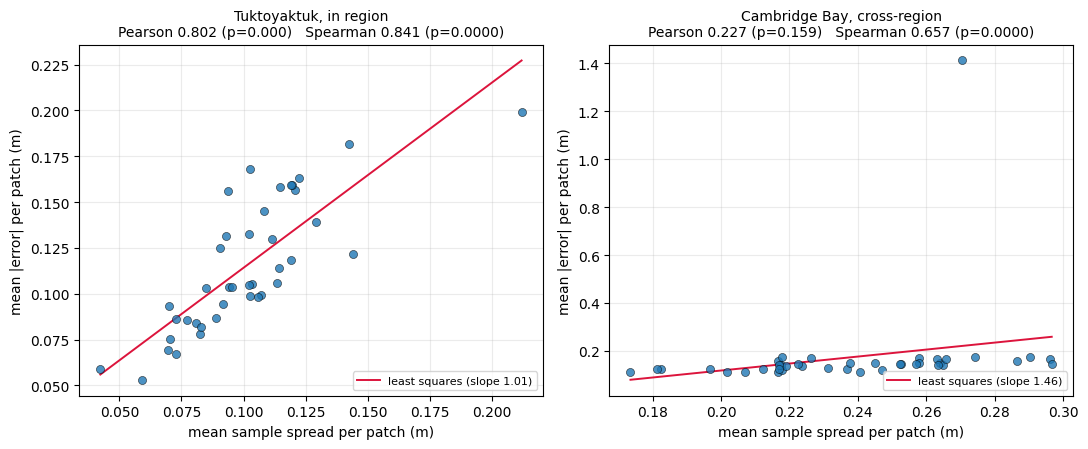

In [5]:
# Patch-level spread vs error, in region and cross-region.
# CPU only. Reads the saved calibration JSONs from pcrtc/07 (fixed) and pcrtc/13.

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

OUT = Path('/cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs')
PANELS = [
    ('Tuktoyaktuk, in region', 's1_tuk_pcrtc_realattrs_spatialsplit_uncertainty_calibration.json'),
    ('Cambridge Bay, cross-region', 's1_pcrtc_cambridgebay_crossregion_uncertainty_calibration.json'),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, (title, name) in zip(axes, PANELS):
    d = json.load(open(OUT / name))
    rows = d['per_patch']
    x = np.array([r['mean_std'] for r in rows], dtype=float)
    y = np.array([r['mean_abs_error'] for r in rows], dtype=float)

    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)

    ax.scatter(x, y, s=34, alpha=0.8, edgecolor='k', linewidth=0.4, zorder=3)

    # least-squares line across the observed range
    b, a = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, a + b * xs, lw=1.4, color='crimson', zorder=2,
            label=f'least squares (slope {b:.2f})')

    ax.set_title(f'{title}\nPearson {pr:.3f} (p={pp:.3f})   Spearman {sr:.3f} (p={sp:.4f})',
                 fontsize=10)
    ax.set_xlabel('mean sample spread per patch (m)')
    ax.set_ylabel('mean |error| per patch (m)')
    ax.grid(alpha=0.25, zorder=0)
    ax.legend(fontsize=8, loc='lower right')

    # outlier sensitivity: drop the single point with the largest residual
    resid = np.abs(y - (a + b * x))
    k = int(np.argmax(resid))
    keep = np.ones(len(x), bool); keep[k] = False
    pr2, pp2 = pearsonr(x[keep], y[keep])
    print(f'{title}')
    print(f'   n = {len(x)}   spread range {x.min():.4f}-{x.max():.4f} m'
          f'   error range {y.min():.4f}-{y.max():.4f} m')
    print(f'   Pearson {pr:.4f} (p={pp:.3f})   Spearman {sr:.4f} (p={sp:.4f})')
    print(f'   drop largest-residual patch ({rows[k]["patch_id"]}): '
          f'Pearson {pr2:.4f} (p={pp2:.3f})\n')

fig.tight_layout()
out_path = OUT / 's1_uncertainty_patch_scatter.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print('Saved:', out_path)
